# Readout power optimization

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal15_readout_power_optimization import ReadoutPowerOptimization

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "readout_power_optimization"

QUBITS = ["q1"]
AMPLITUDE_START = 0.001
AMPLITUDE_STOP = 0.04
AMPLITUDE_POINTS = 20
REPETITIONS = 500
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)
MULTIPLEXED = True  # True: drive/read out all qubits together (with crosstalk).
                     # False: each qubit's full protocol runs in isolation.
INLIER_THRESHOLD = 0.98

TIMEOUT = 3 * 3600  # amplitude x repetitions x state grids can take a while
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None to skip persistence

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ReadoutPowerOptimization(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [4]:
dataset = experiment.run_measurement(
    amplitude_start=AMPLITUDE_START,
    amplitude_stop=AMPLITUDE_STOP,
    amplitude_points=AMPLITUDE_POINTS,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    multiplexed=MULTIPLEXED,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/qblox-measurement-nodes/.venv/lib/python3.11/site-packages/qblox_scheduler/operations/gate_library.py:1181: FutureWarning: Using the `acq_channel` argument is deprecated. Use the `acq_label` argument instead.
  warn_acq_channel()


---
---


<xarray.Dataset> Size: 960kB
Dimensions:           (acq_index_S21_q1: 20000)
Coordinates:
  * acq_index_S21_q1  (acq_index_S21_q1) int64 160kB 0 1 2 ... 19997 19998 19999
    state_q1          (acq_index_S21_q1) int64 160kB 0 1 0 1 0 1 ... 0 1 0 1 0 1
    rep_q1            (acq_index_S21_q1) int64 160kB 0 0 0 0 ... 499 499 499 499
    amplitude_q1      (acq_index_S21_q1) float64 160kB 0.001 0.001 ... 0.04 0.04
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 320kB (0.0004902390241622...
Attributes:
    tuid:     20260916-023813-462-7402bd

## Optional: Simulated data

In [5]:
# dataset = experiment.simulated_data(
#     amplitude_start=AMPLITUDE_START,
#     amplitude_stop=AMPLITUDE_STOP,
#     amplitude_points=AMPLITUDE_POINTS,
#     repetitions=300,
#     ground_iq=0.0,
#     excited_iq=0.3 + 0.2j,
#     noise=0.03,
#     seed=42,
# )

## Analysis

In [6]:
results = experiment.analysis(inlier_threshold=INLIER_THRESHOLD)
for qubit, result in results.items():
    if result.success:
        print(f"{qubit}: best amplitude = {result.best_amplitude:.4f} | "
              f"readout fidelity = {result.readout_fidelity * 100:.2f}%")
    else:
        print(f"{qubit}: discriminator fit failed at the best amplitude")

q1: best amplitude = 0.0400 | readout fidelity = 73.80%


/home/reny871224/qblox-measurement-nodes/.venv/lib/python3.11/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


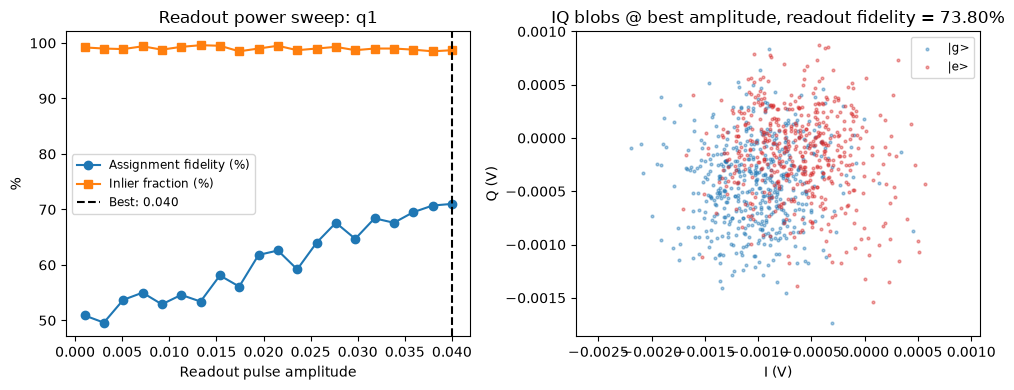

In [7]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [8]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [9]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [10]:
from qcodes.instrument import Instrument

Instrument.close_all()